## 1. Data Preparation

In this section, the credit approval dataset is loaded into a pandas DataFrame. 
The dataset is then inspected to understand its structure, including the number 
of observations, variables, and data types. Finally, the prepared dataset is 
saved as a CSV file for further analysis.

In [265]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
Demo = pd.read_csv("crx.data", header=None)

# Give the columns meaningful names
Demo.columns = [
    "A1", "A2", "A3", "A4", "A5",
    "A6", "A7", "A8", "A9", "A10",
    "A11", "A12", "A13", "A14", "A15",
    "Class"
]

# Display the first five rows
print(Demo.head())

# Display the shape
print(Demo.shape)

# Display information about the dataset
print(Demo.info())

# Save the prepared dataset
Demo.to_csv("credit_approval_prepared.csv", index=False)

  A1     A2     A3 A4 A5 A6 A7    A8 A9 A10  A11 A12 A13    A14  A15 Class
0  b  30.83  0.000  u  g  w  v  1.25  t   t    1   f   g  00202    0     +
1  a  58.67  4.460  u  g  q  h  3.04  t   t    6   f   g  00043  560     +
2  a  24.50  0.500  u  g  q  h  1.50  t   f    0   f   g  00280  824     +
3  b  27.83  1.540  u  g  w  v  3.75  t   t    5   t   g  00100    3     +
4  b  20.17  5.625  u  g  w  v  1.71  t   f    0   f   s  00120    0     +
(690, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      690 non-null    object 
 1   A2      690 non-null    object 
 2   A3      690 non-null    float64
 3   A4      690 non-null    object 
 4   A5      690 non-null    object 
 5   A6      690 non-null    object 
 6   A7      690 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null   

## 2. Exploratory Data Analysis

### 2.1 Checking for Missing Values

In this section, we check the dataset for missing values. Missing values can affect
the performance of machine learning models, so they need to be identified and
handled during the preprocessing stage.

In [267]:
# Check the number of missing values in each column
print(Demo.isnull().sum())
# Check for '?' values, which represent missing values in the dataset
print((Demo == "?").sum())

A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
A10      0
A11      0
A12      0
A13      0
A14      0
A15      0
Class    0
dtype: int64
A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64


In [268]:
# Calculate the total number of missing values represented by '?'
total_missing = (Demo == "?").sum().sum()

print("Total missing values:", total_missing)

Total missing values: 67


### 2.2 Statistical Summary

The statistical summary is used to understand the distribution of the numerical
variables in the dataset. It provides information such as the mean, standard
deviation, minimum, maximum, and quartile values.

In [270]:
# Display the statistical summary of the numerical variables
print(Demo.describe())

               A3          A8        A11            A15
count  690.000000  690.000000  690.00000     690.000000
mean     4.758725    2.223406    2.40000    1017.385507
std      4.978163    3.346513    4.86294    5210.102598
min      0.000000    0.000000    0.00000       0.000000
25%      1.000000    0.165000    0.00000       0.000000
50%      2.750000    1.000000    0.00000       5.000000
75%      7.207500    2.625000    3.00000     395.500000
max     28.000000   28.500000   67.00000  100000.000000


In [271]:
# Display a summary of both numerical and categorical variables
print(Demo.describe(include="all"))

         A1   A2          A3   A4   A5   A6   A7          A8   A9  A10  \
count   690  690  690.000000  690  690  690  690  690.000000  690  690   
unique    3  350         NaN    4    4   15   10         NaN    2    2   
top       b    ?         NaN    u    g    c    v         NaN    t    f   
freq    468   12         NaN  519  519  137  399         NaN  361  395   
mean    NaN  NaN    4.758725  NaN  NaN  NaN  NaN    2.223406  NaN  NaN   
std     NaN  NaN    4.978163  NaN  NaN  NaN  NaN    3.346513  NaN  NaN   
min     NaN  NaN    0.000000  NaN  NaN  NaN  NaN    0.000000  NaN  NaN   
25%     NaN  NaN    1.000000  NaN  NaN  NaN  NaN    0.165000  NaN  NaN   
50%     NaN  NaN    2.750000  NaN  NaN  NaN  NaN    1.000000  NaN  NaN   
75%     NaN  NaN    7.207500  NaN  NaN  NaN  NaN    2.625000  NaN  NaN   
max     NaN  NaN   28.000000  NaN  NaN  NaN  NaN   28.500000  NaN  NaN   

              A11  A12  A13    A14            A15 Class  
count   690.00000  690  690    690     690.000000   6

### 2.3 Distribution of Numerical Variables

Histograms are used to visualize the distribution of the numerical variables.
They help us understand the spread of the data and identify unusual values
that may require further investigation.

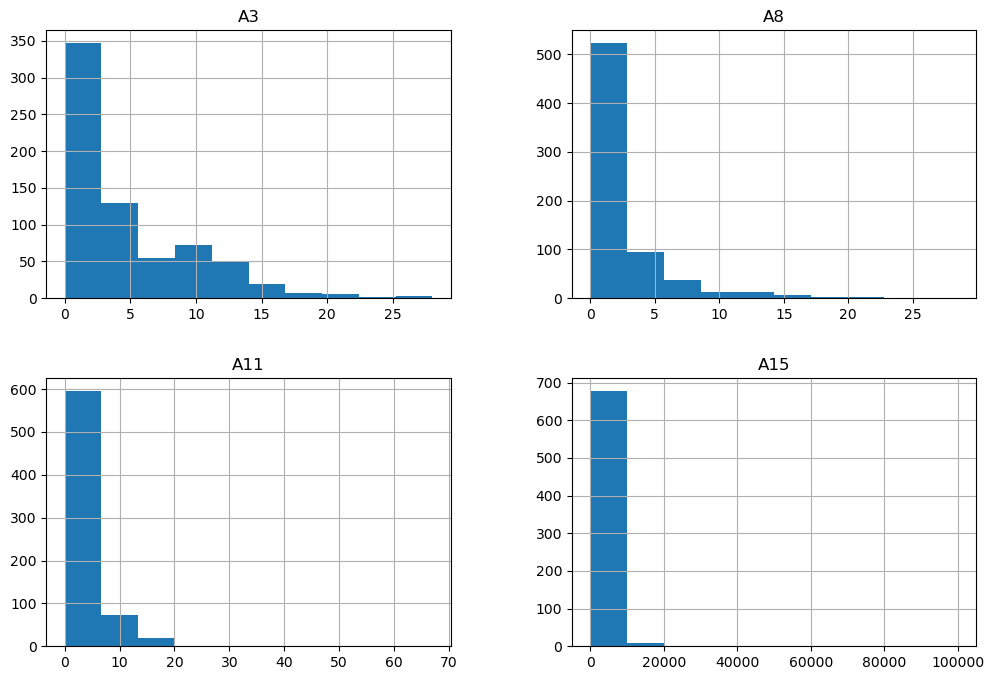

In [273]:
# Select the numerical columns
numeric_columns = ["A2", "A3", "A8", "A11", "A14", "A15"]

# Create histograms for the numerical variables
Demo[numeric_columns].hist(figsize=(12, 8))

# Display the plots
plt.show()

### 2.4 Distribution of the Target Variable

The target variable, `Class`, represents the credit approval outcome.
A bar chart is used to examine the number of observations in each class.

Class
-    383
+    307
Name: count, dtype: int64


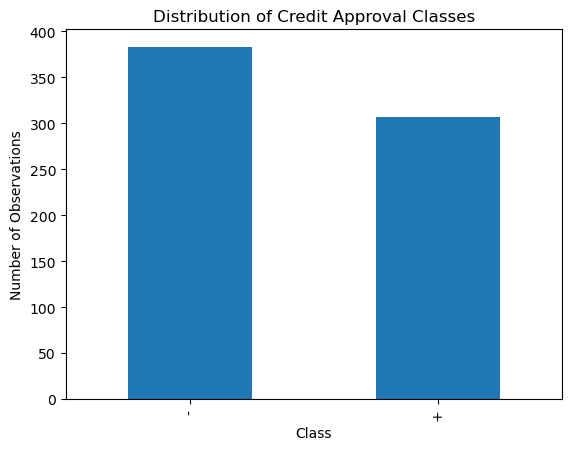

In [275]:
# Count the observations in each class
class_counts = Demo["Class"].value_counts()

# Display the class counts
print(class_counts)

# Create a bar chart for the target variable
class_counts.plot(kind="bar")

# Add a title and labels
plt.title("Distribution of Credit Approval Classes")
plt.xlabel("Class")
plt.ylabel("Number of Observations")

# Display the plot
plt.show()

### 2.5 Identifying Outliers

Boxplots are used to identify potential outliers in the numerical variables.
Values that appear outside the whiskers of a boxplot may be considered
potential outliers.

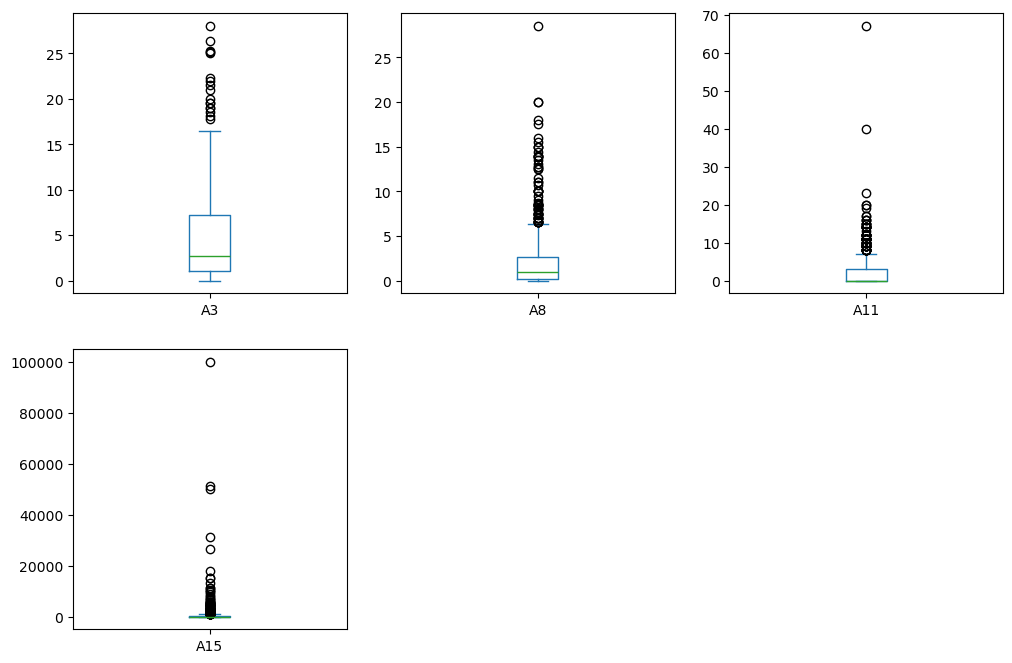

In [277]:
# Create boxplots for the numerical variables
Demo[numeric_columns].plot(
    kind="box",
    subplots=True,
    layout=(2, 3),
    figsize=(12, 8)
)

# Display the plots
plt.show()

### 2.6 Quantitative Identification of Outliers

The Interquartile Range (IQR) method is used to identify potential outliers.
An observation is considered a potential outlier if it falls below
Q1 - 1.5 × IQR or above Q3 + 1.5 × IQR.

In [279]:
# Convert the numerical columns from strings to numeric values
for column in numeric_columns:
    Demo[column] = pd.to_numeric(Demo[column], errors="coerce")

# Calculate the first quartile (Q1)
Q1 = Demo[numeric_columns].quantile(0.25)

# Calculate the third quartile (Q3)
Q3 = Demo[numeric_columns].quantile(0.75)

# Calculate the interquartile range (IQR)
IQR = Q3 - Q1

# Calculate the lower boundary
lower_bound = Q1 - 1.5 * IQR

# Calculate the upper boundary
upper_bound = Q3 + 1.5 * IQR

# Identify the number of potential outliers in each numerical column
outliers = ((Demo[numeric_columns] < lower_bound) |
            (Demo[numeric_columns] > upper_bound)).sum()

# Display the number of potential outliers
print("Number of potential outliers in each numerical column:")
print(outliers)

Number of potential outliers in each numerical column:
A2      16
A3      17
A8      63
A11     79
A14     13
A15    113
dtype: int64


## 3. Preprocessing, Feature Selection and Engineering

### 3.1 Handling Missing Values

The dataset uses the character `?` to represent missing values. These values are
first replaced with NaN so that they can be properly identified and handled.

In [281]:
# Replace '?' with NaN to represent missing values
Demo = Demo.replace("?", np.nan)

# Check the number of missing values in each column
print("Missing values in each column:")
print(Demo.isnull().sum())

Missing values in each column:
A1       12
A2       12
A3        0
A4        6
A5        6
A6        9
A7        9
A8        0
A9        0
A10       0
A11       0
A12       0
A13       0
A14      13
A15       0
Class     0
dtype: int64


### 3.2 Identifying Numerical and Categorical Variables

The dataset contains both numerical and categorical variables. The variables are
separated because different methods will be used to handle their missing values
and encode them for machine learning.

In [283]:
# Define the numerical columns
numeric_columns = ["A2", "A3", "A8", "A11", "A14", "A15"]

# Define the categorical columns
categorical_columns = [
    "A1", "A4", "A5", "A6", "A7",
    "A9", "A10", "A12", "A13"
]

# Display the numerical columns
print("Numerical columns:")
print(numeric_columns)

# Display the categorical columns
print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['A2', 'A3', 'A8', 'A11', 'A14', 'A15']

Categorical columns:
['A1', 'A4', 'A5', 'A6', 'A7', 'A9', 'A10', 'A12', 'A13']


### 3.3 Handling Missing Numerical Values

Missing values in numerical variables are replaced with the median of their
respective columns. The median is used because it is less sensitive to
potential outliers than the mean.

In [285]:
# Fill missing values in numerical columns using the median
for column in numeric_columns:
    Demo[column] = Demo[column].fillna(Demo[column].median())

# Check that numerical missing values have been handled
print("Missing numerical values:")
print(Demo[numeric_columns].isnull().sum())

Missing numerical values:
A2     0
A3     0
A8     0
A11    0
A14    0
A15    0
dtype: int64


### 3.4 Handling Missing Categorical Values

Missing values in categorical variables are replaced with the most frequent
value (mode) in each column. This allows us to retain the observations while
using a value that already exists in the dataset.

In [287]:
# Fill missing values in categorical columns using the mode
for column in categorical_columns:
    Demo[column] = Demo[column].fillna(Demo[column].mode()[0])

# Check that categorical missing values have been handled
print("Missing categorical values:")
print(Demo[categorical_columns].isnull().sum())

Missing categorical values:
A1     0
A4     0
A5     0
A6     0
A7     0
A9     0
A10    0
A12    0
A13    0
dtype: int64


In [288]:
# Check the total number of missing values after handling them
print("Total missing values after preprocessing:")
print(Demo.isnull().sum().sum())

Total missing values after preprocessing:
0


### 3.5 Encoding the Target Variable

The target variable `Class` contains two categories: `+` for approved applications
and `-` for rejected applications. These categories are converted into numerical
values so that they can be used by the classification model.

In [290]:
# Encode the target variable
Demo["Class"] = Demo["Class"].map({"+": 1, "-": 0})

# Display the encoded target values
print(Demo["Class"].value_counts())

Class
0    383
1    307
Name: count, dtype: int64


### 3.6 Encoding Categorical Features

The categorical predictor variables are converted into numerical values using
one-hot encoding. This creates separate binary columns for the different
categories without introducing an artificial numerical order.

In [292]:
# Convert categorical variables into numerical variables using one-hot encoding
Demo = pd.get_dummies(
    Demo,
    columns=categorical_columns,
    drop_first=True
)

# Display the first five rows after encoding
print(Demo.head())

# Display the new shape of the dataset
print("Shape after encoding:", Demo.shape)

      A2     A3    A8  A11    A14  A15  Class   A1_b  A4_u   A4_y  ...   A7_j  \
0  30.83  0.000  1.25    1  202.0    0      1   True  True  False  ...  False   
1  58.67  4.460  3.04    6   43.0  560      1  False  True  False  ...  False   
2  24.50  0.500  1.50    0  280.0  824      1  False  True  False  ...  False   
3  27.83  1.540  3.75    5  100.0    3      1   True  True  False  ...  False   
4  20.17  5.625  1.71    0  120.0    0      1   True  True  False  ...  False   

    A7_n   A7_o   A7_v   A7_z  A9_t  A10_t  A12_t  A13_p  A13_s  
0  False  False   True  False  True   True  False  False  False  
1  False  False  False  False  True   True  False  False  False  
2  False  False  False  False  True  False  False  False  False  
3  False  False   True  False  True   True   True  False  False  
4  False  False   True  False  True  False  False  False   True  

[5 rows x 38 columns]
Shape after encoding: (690, 38)


### 3.7 Checking Data Types

After encoding the categorical variables, the data types are checked to ensure
that the dataset is suitable for machine learning.

In [294]:
# Display the data types after encoding
print(Demo.dtypes)

A2       float64
A3       float64
A8       float64
A11        int64
A14      float64
A15        int64
Class      int64
A1_b        bool
A4_u        bool
A4_y        bool
A5_gg       bool
A5_p        bool
A6_c        bool
A6_cc       bool
A6_d        bool
A6_e        bool
A6_ff       bool
A6_i        bool
A6_j        bool
A6_k        bool
A6_m        bool
A6_q        bool
A6_r        bool
A6_w        bool
A6_x        bool
A7_dd       bool
A7_ff       bool
A7_h        bool
A7_j        bool
A7_n        bool
A7_o        bool
A7_v        bool
A7_z        bool
A9_t        bool
A10_t       bool
A12_t       bool
A13_p       bool
A13_s       bool
dtype: object


In [295]:
# Convert Boolean columns to integer values
Demo = Demo.astype(int)

# Display the data types after conversion
print(Demo.dtypes)

A2       int64
A3       int64
A8       int64
A11      int64
A14      int64
A15      int64
Class    int64
A1_b     int64
A4_u     int64
A4_y     int64
A5_gg    int64
A5_p     int64
A6_c     int64
A6_cc    int64
A6_d     int64
A6_e     int64
A6_ff    int64
A6_i     int64
A6_j     int64
A6_k     int64
A6_m     int64
A6_q     int64
A6_r     int64
A6_w     int64
A6_x     int64
A7_dd    int64
A7_ff    int64
A7_h     int64
A7_j     int64
A7_n     int64
A7_o     int64
A7_v     int64
A7_z     int64
A9_t     int64
A10_t    int64
A12_t    int64
A13_p    int64
A13_s    int64
dtype: object


### 3.8 Separating Features and Target

The dataset is divided into input features (X) and the target variable (y).
The features will be used by the machine learning model to predict whether
a credit application is approved or rejected.

# Separate the features from the target variable
X = Demo.drop("Class", axis=1)

# Store the target variable separately
y = Demo["Class"]

# Display the shape of the features
print("Features shape:", X.shape)

# Display the shape of the target
print("Target shape:", y.shape)

### 3.9 Train-Test Split

The dataset is divided into training and testing sets. The training set is used
to train the machine learning model, while the testing set is used to evaluate
how well the model performs on unseen data. An 80:20 split is used.

In [299]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the shapes of the training and testing sets
print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (552, 37)
Testing features: (138, 37)
Training target: (552,)
Testing target: (138,)


### 3.10 Feature Scaling

Feature scaling is performed to put the numerical features on a similar scale.
StandardScaler is used to standardize the features. The scaler is fitted only
on the training data to prevent information from the testing data from leaking
into the model training process.

In [301]:
# Separate the features from the target variable
X = Demo.drop("Class", axis=1)

# Store the target variable separately
y = Demo["Class"]

# Display the data types of the features
print("Feature data types:")
print(X.dtypes)

Feature data types:
A2       int64
A3       int64
A8       int64
A11      int64
A14      int64
A15      int64
A1_b     int64
A4_u     int64
A4_y     int64
A5_gg    int64
A5_p     int64
A6_c     int64
A6_cc    int64
A6_d     int64
A6_e     int64
A6_ff    int64
A6_i     int64
A6_j     int64
A6_k     int64
A6_m     int64
A6_q     int64
A6_r     int64
A6_w     int64
A6_x     int64
A7_dd    int64
A7_ff    int64
A7_h     int64
A7_j     int64
A7_n     int64
A7_o     int64
A7_v     int64
A7_z     int64
A9_t     int64
A10_t    int64
A12_t    int64
A13_p    int64
A13_s    int64
dtype: object


In [302]:
from sklearn.preprocessing import StandardScaler

# Create the StandardScaler
scaler = StandardScaler()

# Fit the scaler using only the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the fitted scaler to transform the testing data
X_test_scaled = scaler.transform(X_test)

# Display the shapes of the scaled datasets
print("Scaled training data shape:", X_train_scaled.shape)
print("Scaled testing data shape:", X_test_scaled.shape)

Scaled training data shape: (552, 37)
Scaled testing data shape: (138, 37)


In [303]:
scaler.fit_transform(X_train)
scaler.transform(X_test)

array([[ 0.2546141 , -0.47264183, -0.56487508, ...,  1.09508136,
        -0.11333153, -0.31211457],
       [ 0.51124281, -0.47264183, -0.56487508, ...,  1.09508136,
        -0.11333153, -0.31211457],
       [-1.02852941, -0.86175189, -0.26389917, ..., -0.91317416,
        -0.11333153, -0.31211457],
       ...,
       [-1.02852941,  0.88924336, -0.56487508, ..., -0.91317416,
        -0.11333153, -0.31211457],
       [-0.94298651, -0.86175189,  0.03707674, ...,  1.09508136,
        -0.11333153,  3.20395164],
       [ 3.24861563,  0.30557828, -0.56487508, ..., -0.91317416,
        -0.11333153,  3.20395164]])

### 3.11 Checking the Prepared Dataset

The processed training and testing data are checked before model development.
This ensures that the data has been successfully prepared for machine learning.

In [305]:
# Check for missing values in the features
print("Missing values in X:")
print(X.isnull().sum().sum())

# Check the target values
print("\nTarget classes:")
print(y.value_counts())

# Display the first five rows of the scaled training data
print("\nFirst five rows of scaled training data:")
print(X_train_scaled[:5])

Missing values in X:
0

Target classes:
Class
0    383
1    307
Name: count, dtype: int64

First five rows of scaled training data:
[[-4.29729101e-01  6.94688334e-01 -2.63899171e-01 -4.92495602e-01
  -1.27294643e-01 -1.66000001e-01 -1.51185789e+00  5.29851356e-01
  -5.24239249e-01 -6.03022689e-02 -5.24239249e-01 -5.24239249e-01
  -2.48069469e-01 -1.98866846e-01 -1.98866846e-01 -3.01511345e-01
  -2.94302860e-01 -1.21267813e-01 -2.75723397e-01 -2.52158313e-01
  -3.62142984e-01 -7.39221271e-02 -3.12114573e-01 -2.43928186e-01
  -9.56073628e-02 -3.15597202e-01 -4.70360434e-01 -1.04828484e-01
  -7.39221271e-02 -6.03022689e-02  8.14033539e-01 -1.21267813e-01
   9.50498962e-01 -8.86796350e-01 -9.13174158e-01 -1.13331534e-01
  -3.12114573e-01]
 [-2.58643299e-01 -8.61751891e-01 -5.64875084e-01 -4.92495602e-01
   2.48865117e-01 -1.67864054e-01  6.61437828e-01  5.29851356e-01
  -5.24239249e-01 -6.03022689e-02 -5.24239249e-01  1.90752601e+00
  -2.48069469e-01 -1.98866846e-01 -1.98866846e-01 -3.0151

## 4. Model Creation and Evaluation

### 4.1 Logistic Regression

A Logistic Regression classification model is built to predict whether a credit
application will be approved or rejected. Accuracy and F1-score are used to
evaluate the model. Accuracy measures the overall proportion of correct
predictions, while F1-score considers both precision and recall and is useful
when the classes may not be perfectly balanced.

In [307]:
from sklearn.linear_model import LogisticRegression

# Create the Logistic Regression model
model = LogisticRegression(random_state=42)

# Train the model using the scaled training data
model.fit(X_train_scaled, y_train)

# Make predictions on the testing data
y_pred = model.predict(X_test_scaled)

# Display the first few predictions
print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[1 1 0 0 1 1 0 1 0 1]


### 4.3 Model Evaluation

The Logistic Regression model is evaluated using accuracy and F1-score.
Accuracy measures the overall percentage of correct predictions, while the
F1-score provides a balance between precision and recall.

In [309]:
from sklearn.metrics import accuracy_score, f1_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate F1-score
f1 = f1_score(y_test, y_pred)

# Display the evaluation results
print("Accuracy:", accuracy)
print("F1-score:", f1)

Accuracy: 0.8623188405797102
F1-score: 0.8455284552845529


In [310]:
# Display the evaluation metrics as percentages
print("Accuracy: {:.2f}%".format(accuracy * 100))
print("F1-score: {:.2f}%".format(f1 * 100))

Accuracy: 86.23%
F1-score: 84.55%
